## Code for testing model inference

In [1]:
# Imports

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, IterableDataset, get_worker_info
from torchvision_vit import VisionTransformer, Encoder

import cadquery as cq
from cadquery import *
import matplotlib.pyplot as plt

from no_interaction_vis import no_interact_show
from vocabularies import vocabularies
from dataset import CADImageDataset, Tokenizer, collate_fn

import os
import yaml
import wandb
import train_autoregressive

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [9]:
# Loading model and config
# repo_dir = os.path.expanduser("~/treecad-280")

config = yaml.safe_load(
    open(os.path.join("../config/default_config.yaml"), "r")
)

# Load model
checkpoint_path = os.path.join("/data/nzxyin/treecad/ckpt/model_weights_crimson-water-191_99000.pth")
model = train_autoregressive.BaselineCADGenerator(config['vocab_size'])
model.load_state_dict(torch.load(checkpoint_path))
model.to(device)
model.eval()

BaselineCADGenerator(
  (encoder): VisionTransformer(
    (conv_proj): Conv2d(3, 512, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=512, out_features=2048, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=2048, out_features=512, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          

In [39]:
dataset = CADImageDataset(False)
tokenizer = Tokenizer(vocabularies)

In [40]:
batch = collate_fn([dataset[1]])
tokenized_inputs = batch["decoder_inputs"].cuda()  # (B, 512)
targets = batch["targets"].cuda()  # (B, 512)
tgt_masks = batch["attention_masks"].cuda()  # (B, 512)
rolls = batch["rolls"].cuda()  # (B, k)
elevations = batch["elevations"].cuda()  # (B, k)
renderings = batch["renderings"].cuda()  # tensor (B x k x 3 x 128 x 128)
renderings.shape

torch.Size([1, 8, 128, 128, 3])

In [41]:
train_autoregressive.model_inference_v2(model, renderings, rolls, elevations, tgt_masks, tokenizer)

/data/nzxyin/miniconda3/envs/treecad/lib/python3.11/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Decoded text: <SOS>w0=cq.Workplane('XY',origin=(0,0,-36));w1=cq.Workplane('YZ',origin=(-73,0,0));r=w0.sketch().arc((32,100),(37,93),(41,85)).segment((45,90)).close().assemble().finalize().extrude(-15).union(w1.sketch().segment((-52,-72),(-10,-72)).segment((-10,-66)).arc((16,-52),(33,-28)).arc((33,-22),(36,-18)).arc((30,34),(-10,66)).segment((-10,72)).segment((-52,72)).segment((-52,66)).arc((-100,0),(-52,-66)).close().assemble().push([(-31,0)]).circle(30,mode='s').finalize().extrude(146))<EOS>


"<SOS>w0=cq.Workplane('XY',origin=(0,0,-36));w1=cq.Workplane('YZ',origin=(-73,0,0));r=w0.sketch().arc((32,100),(37,93),(41,85)).segment((45,90)).close().assemble().finalize().extrude(-15).union(w1.sketch().segment((-52,-72),(-10,-72)).segment((-10,-66)).arc((16,-52),(33,-28)).arc((33,-22),(36,-18)).arc((30,34),(-10,66)).segment((-10,72)).segment((-52,72)).segment((-52,66)).arc((-100,0),(-52,-66)).close().assemble().push([(-31,0)]).circle(30,mode='s').finalize().extrude(146))<EOS>"

In [62]:
output_cad = tokenizer.detokenize(targets[0][:-1].detach().cpu().tolist())
output_cad

"w0=cq.Workplane('ZX',origin=(0,-100,0));r=w0.sketch().arc((-64,11),(-54,12),(-44,9)).segment((-43,9)).segment((-43,8)).arc((-33,-12),(-43,-31)).segment((-43,-32)).segment((-44,-32)).arc((-49,-34),(-55,-35)).arc((63,13),(-64,11)).assemble().finalize().extrude(200)"

In [70]:
images = train_autoregressive.render_cadquery_code(output_cad, rolls[0], elevations[0])

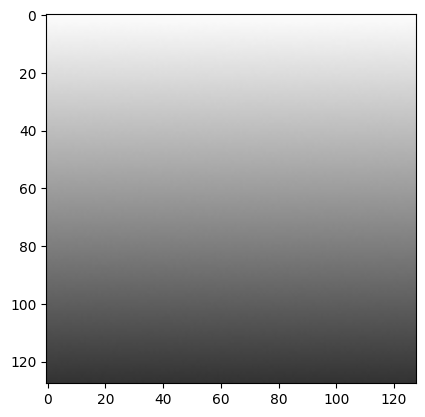

In [78]:
plt.imshow(images[5])